# Deploying a Machine Learning Model for Hiring Process Management

### Data Analysis

In [31]:
!pip install -q -U watermark

In [32]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Basic configs for default charts
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [6, 5]

In [34]:
%reload_ext watermark
%watermark -a "Vinicius Rubens"

Author: Vinicius Rubens



### Loading data

In [35]:
df = pd.read_csv('../data/dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   english_proficiency   300 non-null    float64
 1   cognitive_ability     300 non-null    int64  
 2   aptitude_test_result  300 non-null    int64  
 3   status                300 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 9.5 KB


### EDA

We defined the target variable (target of the study).

Status variable:

- 1 --> Positive class (there was approved)
- 0 --> Negative class (there was no approved)

In [36]:
def eda(data):
    for column in data.columns[:-1]:
        if data[column].dtype in ['int64', 'float64']:
            # Histogram and Boxplot
            fig, axes = plt.subplots(1, 2)
            sns.histplot(data[column], kde = True, ax = axes[0])
            sns.boxplot(x = 'status', y = column, data = data, ax = axes[1])
            axes[0].set_title(f'Distribution of {column}')
            axes[1].set_title(f'{column} vs status')
            plt.tight_layout()
            plt.show()
            
        else:
            # Frequency vs status
            fig, axes = plt.subplots(1, 2)
            sns.countplot(x = column, data = data, ax = axes[0])
            sns.countplot(x = column, hue = 'status', data = data, ax = axes[1])
            axes[0].set_title(f'Distribution of {column}')
            axes[1].set_title(f'{column} vs status')
            plt.tight_layout()
            plt.show()

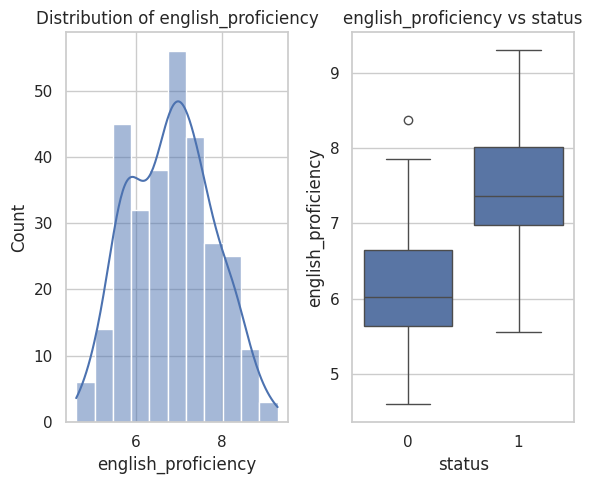

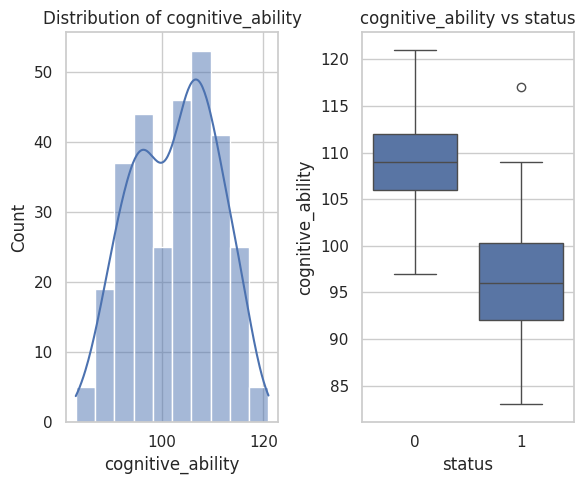

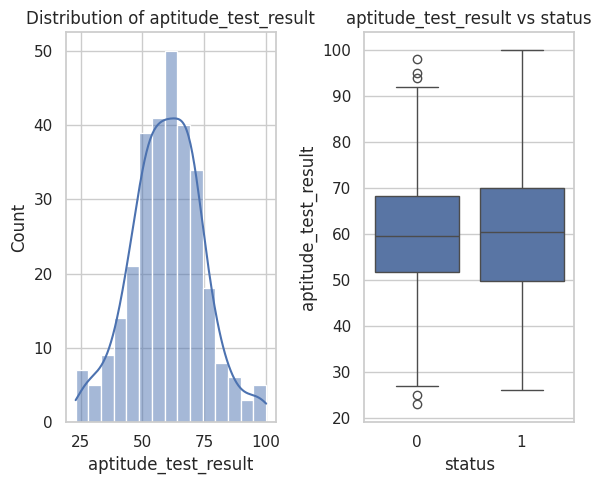

In [37]:
eda(df)

1. Regarding english_proficiency:

- Distribution: The histogram displays a clean distribution with no significant anomalies or outliers.

- Target Relationship: The boxplot reveals that the median score for admitted candidates is higher than for those not admitted. This indicates that higher English proficiency positively correlates with the likelihood of admission.

2. Regarding cognitive_ability:

- Distribution: The histogram shows no data discrepancies or significant anomalies.

- Target Relationship: The boxplot indicates that the median score for non-admitted candidates is higher than for admitted ones. This suggests that a higher cognitive ability level does not, in isolation, guarantee admission.

3. Regarding aptitude_test_result:

- Distribution: The histogram shows no discrepant data.

- Target Relationship: The boxplot demonstrates that the median score is practically identical between admitted and non-admitted candidates.

In [38]:
%watermark -a "Vinicius Rubens"

Author: Vinicius Rubens

